In [5]:
import os
import zipfile
from kaggle.api.kaggle_api_extended import KaggleApi

# Authenticate Kaggle API
api = KaggleApi()
api.authenticate()

# Dataset name
dataset = "ckay16/accident-detection-from-cctv-footage"

# Download path
download_path = "./datasets"

# Create directory if it doesn't exist
os.makedirs(download_path, exist_ok=True)

# Download dataset
print("Downloading dataset...")
api.dataset_download_files(
    dataset,
    path=download_path,
    unzip=False
)

print("Download completed!")

# Find downloaded zip file
zip_file = os.path.join(
    download_path,
    "accident-detection-from-cctv-footage.zip"
)

# Extract dataset
print("Extracting files...")
with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall(download_path)

print("Extraction completed!")
print(f"Dataset available at: {download_path}")

Dataset URL: https://www.kaggle.com/datasets/ckay16/accident-detection-from-cctv-footage
Download completed!
Extracting files...
Extraction completed!
Dataset available at: ./datasets


In [6]:
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense,Conv2D,MaxPooling2D,Flatten,BatchNormalization,Dropout
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

In [8]:

# Training Dataset
train_ds = keras.utils.image_dataset_from_directory(
    directory='datasets/data/train',
    labels='inferred',
    label_mode='int',
    batch_size=32,
    image_size=(256, 256)
)

# Validation Dataset
validation_ds = keras.utils.image_dataset_from_directory(
    directory='datasets/data/test',
    labels='inferred',
    label_mode='int',
    batch_size=32,
    image_size=(256, 256)
)

Found 791 files belonging to 2 classes.
Found 100 files belonging to 2 classes.


In [9]:
# Normalize
def process(image,label):
    image = tf.cast(image/255. ,tf.float32)
    return image,label

train_ds = train_ds.map(process)
validation_ds = validation_ds.map(process)

In [10]:
# Create the CNN model
model = Sequential()

model.add(Conv2D(32,kernel_size=(3,3),padding='valid',activation='relu',input_shape=(256,256,3)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Conv2D(64,kernel_size=(3,3),padding='valid',activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

# model.add(Conv2D(128,kernel_size=(3,3),padding='valid',activation='relu'))
# model.add(BatchNormalization())
# model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Flatten())

model.add(Dense(128,activation='relu'))
model.add(Dropout(0.1))
model.add(Dense(128,activation='relu'))
model.add(Dropout(0.1))
model.add(Dense(64,activation='relu'))
model.add(Dropout(0.1))
model.add(Dense(1,activation='sigmoid'))


c:\Users\richi\DATA SCIENCE - IIT GUWAHATI\DEPLOYMENT\Accident_CNN\myenv\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [11]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 254, 254, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 125, 125, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 246016)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    31,490,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,534,785 (120.30 MB)

 Trainable params: 31,534,593 (120.29 MB)

 Non-trainable params: 192 (768.00 B)

In [12]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

# Set up callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=3)
model_checkpoint = ModelCheckpoint('best_model.h5', monitor='val_loss', save_best_only=True)

In [13]:
history = model.fit(train_ds,epochs=25,validation_data=validation_ds,callbacks= [early_stopping , model_checkpoint] )

# Evaluate the model on the test data
test_loss, test_accuracy = model.evaluate(validation_ds)
print(f"Test Loss: {test_loss}, Test Accuracy: {test_accuracy}")

Epoch 1/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5758 - loss: 9.7501

25/25 ━━━━━━━━━━━━━━━━━━━━ 47s 2s/step - accuracy: 0.5929 - loss: 9.4481 - val_accuracy: 0.5300 - val_loss: 1.7917
Epoch 2/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6234 - loss: 6.8264

25/25 ━━━━━━━━━━━━━━━━━━━━ 43s 2s/step - accuracy: 0.5967 - loss: 7.1595 - val_accuracy: 0.5700 - val_loss: 1.6736
Epoch 3/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 49s 2s/step - accuracy: 0.6233 - loss: 5.4080 - val_accuracy: 0.4700 - val_loss: 2.3195
Epoch 4/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 49s 2s/step - accuracy: 0.6296 - loss: 2.8434 - val_accuracy: 0.4800 - val_loss: 3.0632
Epoch 5/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 49s 2s/step - accuracy: 0.7016 - loss: 2.1865 - val_accuracy: 0.5300 - val_loss: 4.6184
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 158ms/step - accuracy: 0.5300 - loss: 4.6184
Test Loss: 4.618422031402588, Test Accuracy: 0.5299999713897705


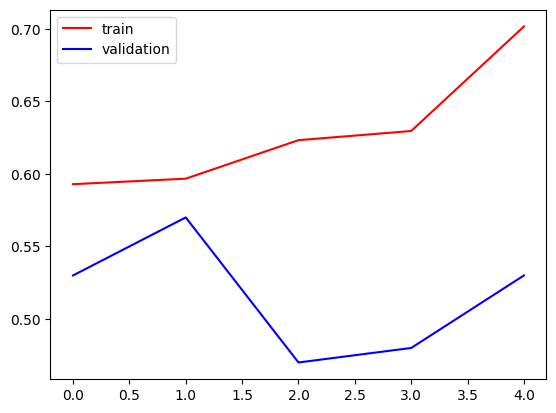

In [14]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'],color='red',label='train')
plt.plot(history.history['val_accuracy'],color='blue',label='validation')
plt.legend()
plt.show()

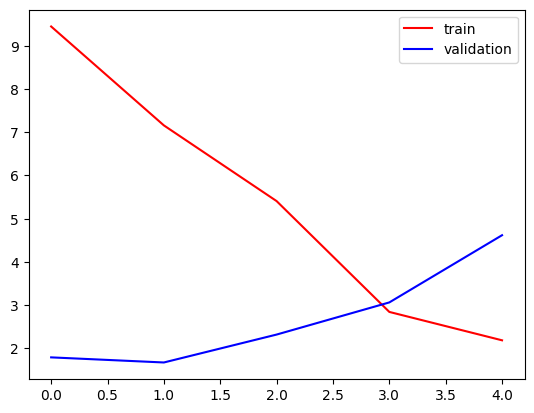

In [15]:
plt.plot(history.history['loss'],color='red',label='train')
plt.plot(history.history['val_loss'],color='blue',label='validation')
plt.legend()
plt.show()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 61s 1us/step
Epoch 1/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.5483 - loss: 1.9433

25/25 ━━━━━━━━━━━━━━━━━━━━ 175s 7s/step - accuracy: 0.6157 - loss: 1.1550 - val_accuracy: 0.6800 - val_loss: 0.5655
Epoch 2/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.7042 - loss: 0.5545

25/25 ━━━━━━━━━━━━━━━━━━━━ 178s 7s/step - accuracy: 0.7105 - loss: 0.5431 - val_accuracy: 0.7800 - val_loss: 0.4606
Epoch 3/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.7709 - loss: 0.4455

25/25 ━━━━━━━━━━━━━━━━━━━━ 174s 7s/step - accuracy: 0.7762 - loss: 0.4440 - val_accuracy: 0.8600 - val_loss: 0.3985
Epoch 4/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.8212 - loss: 0.3974

25/25 ━━━━━━━━━━━━━━━━━━━━ 183s 7s/step - accuracy: 0.8217 - loss: 0.3833 - val_accuracy: 0.9200 - val_loss: 0.3384
Epoch 5/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.8659 - loss: 0.3244

...

25/25 ━━━━━━━━━━━━━━━━━━━━ 915s 38s/step - accuracy: 0.8723 - loss: 0.2986 - val_accuracy: 0.9200 - val_loss: 0.2474
Epoch 7/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.9110 - loss: 0.2499

25/25 ━━━━━━━━━━━━━━━━━━━━ 183s 7s/step - accuracy: 0.9014 - loss: 0.2594 - val_accuracy: 0.9500 - val_loss: 0.1956
Epoch 8/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.9259 - loss: 0.1906

25/25 ━━━━━━━━━━━━━━━━━━━━ 238s 9s/step - accuracy: 0.9216 - loss: 0.2083 - val_accuracy: 0.9400 - val_loss: 0.1894
Epoch 9/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.9457 - loss: 0.1701

25/25 ━━━━━━━━━━━━━━━━━━━━ 3607s 150s/step - accuracy: 0.9254 - loss: 0.1969 - val_accuracy: 0.9500 - val_loss: 0.1700
Epoch 10/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.9453 - loss: 0.1624

25/25 ━━━━━━━━━━━━━━━━━━━━ 190s 8s/step - accuracy: 0.9241 - loss: 0.1824 - val_accuracy: 0.9700 - val_loss: 0.1519
Epoch 11/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 215s 9s/step - accuracy: 0.9216 - loss: 0.1964 - val_accuracy: 0.9500 - val_loss: 0.1519
Epoch 12/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 219s 9s/step - accuracy: 0.9305 - loss: 0.1664 - val_accuracy: 0.9400 - val_loss: 0.1638
Epoch 13/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 173s 7s/step - accuracy: 0.9267 - loss: 0.1818 - val_accuracy: 0.9600 - val_loss: 0.1710
4/4 ━━━━━━━━━━━━━━━━━━━━ 15s 3s/step - accuracy: 0.9600 - loss: 0.1710
Test Loss: 0.17102113366127014, Test Accuracy: 0.9599999785423279


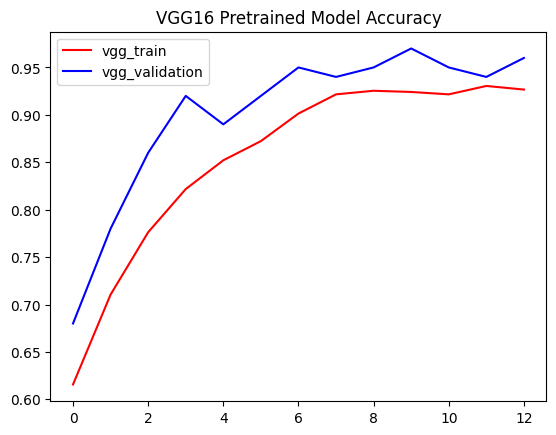

In [ ]:
from keras.applications.vgg16 import VGG16

# Load the VGG16 model with pre-trained ImageNet weights, excluding the top dense layers
conv_base = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(256, 256, 3)
)

# Freeze the convolutional base
conv_base.trainable = False

# Build the model
model_vgg = Sequential([
    conv_base,
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

model_vgg.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Set up callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=3)
model_checkpoint = ModelCheckpoint('best_model_vgg.h5', monitor='val_loss', save_best_only=True)

# Train the model
history_vgg = model_vgg.fit(train_ds, epochs=25, validation_data=validation_ds, callbacks= [early_stopping,model_checkpoint] )

# Evaluate the model on the test data
test_loss, test_accuracy = model_vgg.evaluate(validation_ds)
print(f"Test Loss: {test_loss}, Test Accuracy: {test_accuracy}")

# Visualize accuracy for comparison
plt.plot(history_vgg.history['accuracy'], color='red', label=

gg_train')
plt.plot(history_vgg.history['val_accuracy'], color='blue', label='vgg_validation')
plt.legend()
plt.title('VGG16 Pretrained Model Accuracy')
plt.show()

Epoch 1/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.4861 - loss: 2.2739

25/25 ━━━━━━━━━━━━━━━━━━━━ 134s 5s/step - accuracy: 0.5360 - loss: 1.8581 - val_accuracy: 0.5900 - val_loss: 0.7396
Epoch 2/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.6884 - loss: 0.6776

25/25 ━━━━━━━━━━━━━━━━━━━━ 136s 5s/step - accuracy: 0.6536 - loss: 0.7064 - val_accuracy: 0.7000 - val_loss: 0.6191
Epoch 3/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.6827 - loss: 0.6028

25/25 ━━━━━━━━━━━━━━━━━━━━ 134s 5s/step - accuracy: 0.6827 - loss: 0.5873 - val_accuracy: 0.6700 - val_loss: 0.5596
Epoch 4/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.7079 - loss: 0.5635

25/25 ━━━━━━━━━━━━━━━━━━━━ 135s 5s/step - accuracy: 0.7206 - loss: 0.5384 - val_accuracy: 0.7300 - val_loss: 0.5082
Epoch 5/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.7613 - loss: 0.4850

...

25/25 ━━━━━━━━━━━━━━━━━━━━ 129s 5s/step - accuracy: 0.8281 - loss: 0.4045 - val_accuracy: 0.8500 - val_loss: 0.3823
Epoch 13/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 132s 5s/step - accuracy: 0.8091 - loss: 0.3994 - val_accuracy: 0.8100 - val_loss: 0.3941
Epoch 14/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.8002 - loss: 0.3909

25/25 ━━━━━━━━━━━━━━━━━━━━ 130s 5s/step - accuracy: 0.8116 - loss: 0.3941 - val_accuracy: 0.8500 - val_loss: 0.3702
Epoch 15/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.8545 - loss: 0.3508

25/25 ━━━━━━━━━━━━━━━━━━━━ 130s 5s/step - accuracy: 0.8319 - loss: 0.3766 - val_accuracy: 0.8700 - val_loss: 0.3635
Epoch 16/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.8520 - loss: 0.3242

25/25 ━━━━━━━━━━━━━━━━━━━━ 131s 5s/step - accuracy: 0.8407 - loss: 0.3383 - val_accuracy: 0.8400 - val_loss: 0.3313
Epoch 17/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.8541 - loss: 0.3415

25/25 ━━━━━━━━━━━━━━━━━━━━ 129s 5s/step - accuracy: 0.8331 - loss: 0.3565 - val_accuracy: 0.9000 - val_loss: 0.2948
Epoch 18/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 129s 5s/step - accuracy: 0.8394 - loss: 0.3432 - val_accuracy: 0.8900 - val_loss: 0.3139
Epoch 19/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 128s 5s/step - accuracy: 0.8546 - loss: 0.3249 - val_accuracy: 0.8800 - val_loss: 0.3106
Epoch 20/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 128s 5s/step - accuracy: 0.8293 - loss: 0.3607 - val_accuracy: 0.8700 - val_loss: 0.3332
4/4 ━━━━━━━━━━━━━━━━━━━━ 14s 3s/step - accuracy: 0.8700 - loss: 0.3332
Test Loss: 0.33319297432899475, Test Accuracy: 0.8700000047683716


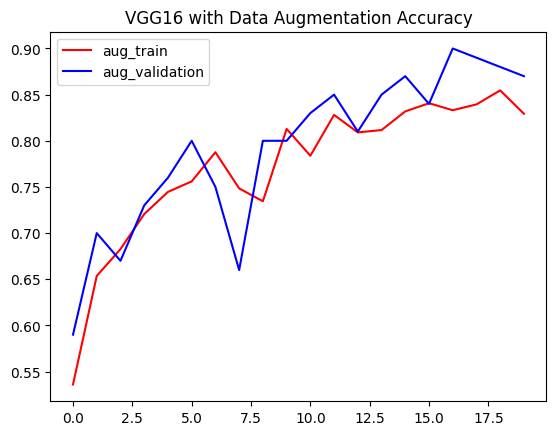

In [17]:
import tensorflow as tf
from tensorflow.keras import layers, Sequential

# Define data augmentation layers
data_augmentation = Sequential([
  layers.RandomFlip("horizontal"),
  layers.RandomRotation(0.1),
  layers.RandomZoom(0.1),
])


# Build a new model incorporating data augmentation
model_aug = Sequential([
    data_augmentation,
    conv_base, # Using the same VGG16 base from previous step
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(1, activation='sigmoid')
])


model_aug.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Set up callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=3)
model_checkpoint = ModelCheckpoint('best_model_aug.h5', monitor='val_loss', save_best_only=True)

# Train the model with augmented data
history_aug = model_aug.fit(train_ds, epochs=25, validation_data=validation_ds, callbacks= [early_stopping,model_checkpoint])

# Evaluate the model on the test data
test_loss, test_accuracy = model_aug.evaluate(validation_ds)
print(f"Test Loss: {test_loss}, Test Accuracy: {test_accuracy}")

# Visualize accuracy for comparison
plt.plot(history_aug.history['accuracy'], color='red', label='aug_train')
plt.plot(history_aug.history['val_accuracy'], color='blue', label='aug_validation')
plt.legend()
plt.title('VGG16 with Data Augmentation Accuracy')
plt.show()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 68s 1us/step
Epoch 1/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.4709 - loss: 6.3396

25/25 ━━━━━━━━━━━━━━━━━━━━ 61s 2s/step - accuracy: 0.4930 - loss: 3.0254 - val_accuracy: 0.5300 - val_loss: 0.6930
Epoch 2/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5069 - loss: 0.6931

25/25 ━━━━━━━━━━━━━━━━━━━━ 56s 2s/step - accuracy: 0.5335 - loss: 0.6930 - val_accuracy: 0.5300 - val_loss: 0.6929
Epoch 3/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5274 - loss: 0.6929

25/25 ━━━━━━━━━━━━━━━━━━━━ 50s 2s/step - accuracy: 0.5335 - loss: 0.6929 - val_accuracy: 0.5300 - val_loss: 0.6928
Epoch 4/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5315 - loss: 0.6928

25/25 ━━━━━━━━━━━━━━━━━━━━ 50s 2s/step - accuracy: 0.5335 - loss: 0.6927 - val_accuracy: 0.5300 - val_loss: 0.6927
Epoch 5/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5350 - loss: 0.6926

...

25/25 ━━━━━━━━━━━━━━━━━━━━ 48s 2s/step - accuracy: 0.5335 - loss: 0.6912 - val_accuracy: 0.5300 - val_loss: 0.6915
Epoch 22/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5597 - loss: 0.6889

25/25 ━━━━━━━━━━━━━━━━━━━━ 48s 2s/step - accuracy: 0.5335 - loss: 0.6912 - val_accuracy: 0.5300 - val_loss: 0.6914
Epoch 23/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5459 - loss: 0.6900

25/25 ━━━━━━━━━━━━━━━━━━━━ 48s 2s/step - accuracy: 0.5335 - loss: 0.6911 - val_accuracy: 0.5300 - val_loss: 0.6914
Epoch 24/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5292 - loss: 0.6915

25/25 ━━━━━━━━━━━━━━━━━━━━ 48s 2s/step - accuracy: 0.5335 - loss: 0.6911 - val_accuracy: 0.5300 - val_loss: 0.6914
Epoch 25/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 54s/step - accuracy: 0.5410 - loss: 0.6904 

25/25 ━━━━━━━━━━━━━━━━━━━━ 1311s 55s/step - accuracy: 0.5335 - loss: 0.6911 - val_accuracy: 0.5300 - val_loss: 0.6914
4/4 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - accuracy: 0.5300 - loss: 0.6914
ResNet50 Test Accuracy: 0.5299999713897705


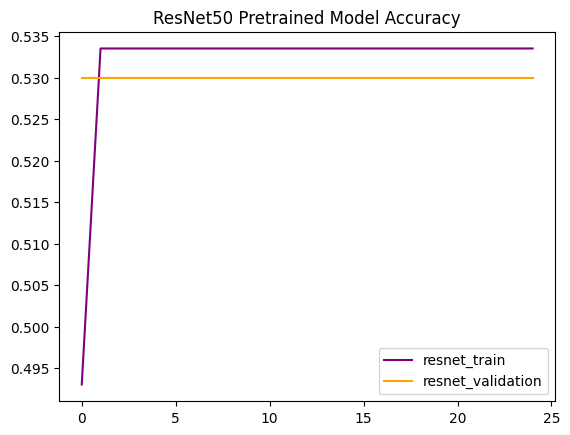

In [18]:
from tensorflow.keras.applications.resnet50 import ResNet50

# Load the ResNet50 model with pre-trained ImageNet weights
resnet_base = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(256, 256, 3)
)

# Freeze the convolutional base
resnet_base.trainable = False

# Build the model
model_resnet = Sequential([
    resnet_base,
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

model_resnet.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Set up callbacks
early_stopping_resnet = EarlyStopping(monitor='val_loss', patience=3)
checkpoint_resnet = ModelCheckpoint('best_model_resnet.h5', monitor='val_loss', save_best_only=True)

# Train the model
history_resnet = model_resnet.fit(train_ds, epochs=25, validation_data=validation_ds, callbacks=[early_stopping_resnet, checkpoint_resnet])

# Evaluate and Visualize
test_loss_res, test_acc_res = model_resnet.evaluate(validation_ds)
print(f"ResNet50 Test Accuracy: {test_acc_res}")

plt.plot(history_resnet.history['accuracy'], color='purple', label='resnet_train')
plt.plot(history_resnet.history['val_accuracy'], color='orange', label='resnet_validation')
plt.legend()
plt.title('ResNet50 Pretrained Model Accuracy')
plt.show()

Epoch 1/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5216 - loss: 3.3381

25/25 ━━━━━━━━━━━━━━━━━━━━ 45s 2s/step - accuracy: 0.5183 - loss: 3.0731 - val_accuracy: 0.5300 - val_loss: 1.4897
Epoch 2/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5626 - loss: 1.3699

25/25 ━━━━━━━━━━━━━━━━━━━━ 44s 2s/step - accuracy: 0.5512 - loss: 1.2638 - val_accuracy: 0.5000 - val_loss: 1.0931
Epoch 3/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5645 - loss: 0.9645

25/25 ━━━━━━━━━━━━━━━━━━━━ 44s 2s/step - accuracy: 0.5449 - loss: 0.9262 - val_accuracy: 0.4700 - val_loss: 0.7137
Epoch 4/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5419 - loss: 0.7115

25/25 ━━━━━━━━━━━━━━━━━━━━ 43s 2s/step - accuracy: 0.5638 - loss: 0.7237 - val_accuracy: 0.5400 - val_loss: 0.7059
Epoch 5/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 43s 2s/step - accuracy: 0.4930 - loss: 0.7941 - val_accuracy: 0.5200 - val_loss: 1.0692
Epoch 6/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 43s 2s/step - accuracy: 0.5196 - loss: 0.7352 - val_accuracy: 0.5500 - val_loss: 1.1421
Epoch 7/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5178 - loss: 0.7708

25/25 ━━━━━━━━━━━━━━━━━━━━ 44s 2s/step - accuracy: 0.4779 - loss: 0.7518 - val_accuracy: 0.4900 - val_loss: 0.7027
Epoch 8/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5421 - loss: 0.6942

25/25 ━━━━━━━━━━━━━━━━━━━━ 46s 2s/step - accuracy: 0.5171 - loss: 0.7031 - val_accuracy: 0.5200 - val_loss: 0.6966
Epoch 9/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5030 - loss: 0.6997

25/25 ━━━━━━━━━━━━━━━━━━━━ 43s 2s/step - accuracy: 0.5133 - loss: 0.7290 - val_accuracy: 0.5300 - val_loss: 0.6742
Epoch 10/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 42s 2s/step - accuracy: 0.5335 - loss: 0.6965 - val_accuracy: 0.5200 - val_loss: 0.7001
Epoch 11/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 42s 2s/step - accuracy: 0.5449 - loss: 0.6916 - val_accuracy: 0.5800 - val_loss: 0.7240
Epoch 12/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5529 - loss: 0.6958

25/25 ━━━━━━━━━━━━━━━━━━━━ 42s 2s/step - accuracy: 0.5360 - loss: 0.7034 - val_accuracy: 0.5600 - val_loss: 0.6612
Epoch 13/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 42s 2s/step - accuracy: 0.5424 - loss: 0.7112 - val_accuracy: 0.5600 - val_loss: 0.6782
Epoch 14/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 43s 2s/step - accuracy: 0.5247 - loss: 0.6857 - val_accuracy: 0.5000 - val_loss: 0.7115
Epoch 15/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 42s 2s/step - accuracy: 0.5322 - loss: 0.6888 - val_accuracy: 0.5200 - val_loss: 0.7162
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 143ms/step - accuracy: 0.5200 - loss: 0.7162
Test Loss: 0.7161828875541687, Test Accuracy: 0.5199999809265137


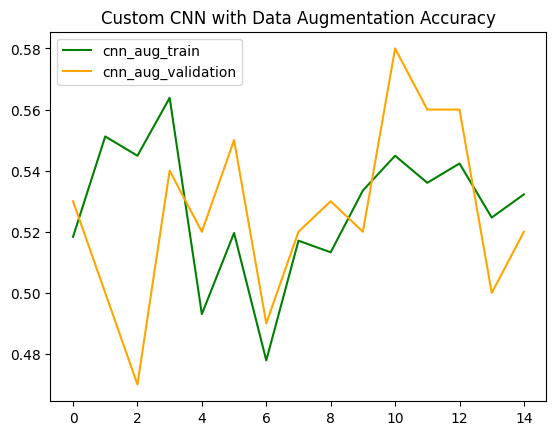

In [19]:
from tensorflow.keras import layers, Sequential

# 1. Define Data Augmentation specifically for the custom CNN
cnn_augmentation = Sequential([
  layers.RandomFlip("horizontal"),
  layers.RandomRotation(0.2),
  layers.RandomZoom(0.2),
])

# 2. Build a new model using the existing 'model' (Custom CNN) and adding augmentation
# We use the 'model' variable which contains your custom architecture
model_cnn_aug = Sequential([
    cnn_augmentation,
    model # This is your custom CNN
])

model_cnn_aug.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Set up callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=3)
model_checkpoint = ModelCheckpoint('best_model_aug.h5', monitor='val_loss', save_best_only=True)

# 3. Train the augmented custom CNN
# We'll call this history_cnn_aug to distinguish it
history_cnn_aug = model_cnn_aug.fit(train_ds, epochs=25, validation_data=validation_ds, callbacks = [early_stopping, model_checkpoint])

# Evaluate the model on the test data
test_loss, test_accuracy = model_cnn_aug.evaluate(validation_ds)
print(f"Test Loss: {test_loss}, Test Accuracy: {test_accuracy}")


# 4. Visualize the results for the augmented Custom CNN
plt.plot(history_cnn_aug.history['accuracy'], color='green', label='cnn_aug_train')
plt.plot(history_cnn_aug.history['val_accuracy'], color='orange', label='cnn_aug_validation')
plt.legend()
plt.title('Custom CNN with Data Augmentation Accuracy')
plt.show()

In [20]:
import pandas as pd


final_comparison = {
    'Model Approach': [
        'Custom CNN (Base)',
        'Pre-trained VGG16',
        'VGG16 + Augmentation',
        'Custom CNN + Augmentation',
        'Pre-trained ResNet50'
    ],
    'Train Accuracy': [
        history.history['accuracy'][-1],
        history_vgg.history['accuracy'][-1],
        history_aug.history['accuracy'][-1],
        history_cnn_aug.history['accuracy'][-1],
        history_resnet.history['accuracy'][-1]
    ],
    'Validation Accuracy': [
        history.history['val_accuracy'][-1],
        history_vgg.history['val_accuracy'][-1],
        history_aug.history['val_accuracy'][-1],
        history_cnn_aug.history['val_accuracy'][-1],
        history_resnet.history['val_accuracy'][-1]
    ],
    'Test Accuracy': [
        model.evaluate(validation_ds, verbose=0)[1],
        model_vgg.evaluate(validation_ds, verbose=0)[1],
        model_aug.evaluate(validation_ds, verbose=0)[1],
        model_cnn_aug.evaluate(validation_ds, verbose=0)[1],
        model_resnet.evaluate(validation_ds, verbose=0)[1]
    ]
}

df_final = pd.DataFrame(final_comparison)
display(df_final)

# Final Recommendation
best_approach = df_final.iloc[df_final['Validation Accuracy'].idxmax()]['Model Approach']
print(f"\nThe best overall approach for accident detection is: {best_approach}")

,Model Approach,Train Accuracy,Validation Accuracy,Test Accuracy
0,Custom CNN (Base),0.701643,0.53,0.52
1,Pre-trained VGG16,0.926675,0.96,0.96
2,VGG16 + Augmentation,0.829330,0.87,0.87
3,Custom CNN + Augmentation,0.532238,0.52,0.52
4,Pre-trained ResNet50,0.533502,0.53,0.53



The best overall approach for accident detection is: Pre-trained VGG16
